!pip install nats_bench

In [1]:
import torch
import numpy as np
import os
import tarfile
from nats_bench import create
import pandas as pd

from torch.utils.data import TensorDataset
from sklearn.decomposition import PCA

from utils_functions.utils import set_seed, decoded_x_to_nas201_arch,build_accuracy_pairs

from dataset_loader import arch_to_tensor,NASDatasetFactory,tensor_to_genotype,genotype_to_tensor
from models.nas201_models import VAE_dist,vae_accuracy_loss
from models.flow import FlowNet

from train_flownas import pretrain_and_freeze_vae
import matplotlib.pyplot as plt
import warnings

from utils_functions.plots_utils import plot_latent_comparison

warnings.filterwarnings("ignore")

c:\Users\tiber\Desktop\em\ALife\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensorflow is not installed.


# Datasets Used

In this work, two benchmark datasets are used: **NAS-Bench-201** and **NAS-Bench-301 / DARTS**.

|               | NAS-Bench-201               | NAS-Bench-301 / DARTS                                          |
| ------------- | --------------------------- | -------------------------------------------------------------- |
| Architectures | 15,625                      | ~10¹⁸ possible architectures, sampled through the search space |
| Structure     | 1 cell, 4 nodes             | 2 cells, normal and reduction, with 4 intermediate nodes each  |
| Operations    | 5                           | 7                                                              |
| Encoding      | ((5, 4, 4) = 80) dimensions | ((2, 7, 6, 6) = 504) dimensions                                |
| Accuracy      | Real lookup table           | Surrogate model, based on an ensemble predictor                |


## NAS-bench-201

In [2]:
# path configuration
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, 'datasets'))
percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

# archive extraction
if not os.path.exists(DATASET_PATH):
    print('Estrazione in corso...')
    with tarfile.open(percorso_tar, 'r') as tar:
        tar.extractall(path=DATASETS_DIR)
    print('Estrazione completata!')
else:
    print('Dataset già estratto.')

# API loading 
api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

An element of the dataset contains: 
- a string representing a DAG where each node is a cell of operations (conv, max pooling)
- results of different datasets 

In [4]:
#architecture string
print(api[0])
#results
info_cifar10 = api.get_more_info(0, 'cifar10', is_random=False)
print('cifar10  test-accuracy:', info_cifar10.get('test-accuracy'))

|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|
cifar10  test-accuracy: 69.55


To work with architectures we use functions to convert string into torch tensor and viceversa:

In [5]:
#converting architecture string into torch tensor
T = arch_to_tensor(arch_str=api[0])
#from torch tensor into architecture string
arch_str = decoded_x_to_nas201_arch(T)

print(T,arch_str)

[[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 1. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 1. 1.]
  [0. 0. 0. 1.]
  [0. 0. 0. 0.]]

 [[0. 1. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]] |avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


In [6]:
#converting all elements of dataset into tensor
all_tensors = []
for i in range(len(api)):
    arch_str = api[i]
    A = arch_to_tensor(arch_str)
    all_tensors.append(A)

X = np.stack(all_tensors)  # shape: (N_architetture, 6, 4, 4)
print('X shape:', X.shape)

X = torch.tensor(X)      
X = X.view(len(X), -1)    # flatten, shape:  (N_architetture, 96)
print('X shape:', X.shape)

X shape: (15625, 5, 4, 4)
X shape: torch.Size([15625, 80])


### data loading 

The `NASDatasetFactory.create()` method takes as input the name of the benchmark and returns the train and test dataset and loader.

In [7]:
train_dataset,test_dataset,train_laoder,test_loader = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",
    metric="test-accuracy",
    hp="12",
    flatten=True,
    normalize_y=True
)

In [8]:
print(len(train_dataset), len(test_dataset))

12500 3125


### VAE for NAS201 

Summary of the architecture of the VAE used for NAS201, the DARTS/NAS301 VAE will be deeper in order to handle a substantially larger architectural encoding.

|  | NATS-Bench VAE | 
|---|---|
| Input dimension | 80 | 
| Latent dimension | 16 | 
| Encoder | 80 → 128 → 64 → (μ, logσ²) |
| Decoder | 16 → 128 → 128 → 80 | 
| Output shape | (4, 4, 5) | 

The loss used is **vae_accuracy_loss**:
$$\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
\beta \, \mathcal{L}_{KL}
+
\lambda_{acc} \, \mathcal{L}_{acc}$$
where: 
- $\mathcal{L}_{rec}$ is the reconstruction loss
- $\mathcal{L}_{KL}$ is the KL divergence
- $\mathcal{L}_{acc}$ is the MSE between the predicted accuracy and the ground-truth accuracy provided by the benchmark.



In [9]:
SEED = 46
set_seed(SEED)
model = VAE_dist().to(DEVICE)
loss_fn = vae_accuracy_loss

#### VAE training 

the `pretrain_and_freeze_vae()` function trains the **VAE** using the function for the loss given in input

In the following section we'll train a VAE, we'll consider the loss with and without the term using the accuracy and we'll plot the principal components of the resulting latent space.
With $\lambda$ = 0:

In [10]:

model_no_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=100,
    beta=1.3,
    lambda_acc=0,
    DEVICE=DEVICE,
)

VAE pretrain epoch 000 | loss=0.736205 | recon=0.731274 | kl=0.003793 | acc_loss=0.000000
VAE pretrain epoch 050 | loss=0.603770 | recon=0.603698 | kl=0.000056 | acc_loss=0.000000
VAE pretrained and frozen.


In [11]:
model.eval()
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))]).to(DEVICE)
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))]).to(DEVICE)

with torch.no_grad():
    mu, logvar = model_no_acc.encode(X_train)
    z = mu  
z = z.cpu().numpy()  

pca = PCA(n_components=2)
z_2d_vae = pca.fit_transform(z)

with $\lambda = 1$

In [12]:
set_seed(SEED)
model = VAE_dist().to(DEVICE)
model.train()
model_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=100,
    beta=1.3,
    lambda_acc=1,
    DEVICE=DEVICE,
    early_stop=False,
    freeze_after=False,
    lr=1e-3
)

VAE pretrain epoch 000 | loss=0.889606 | recon=0.729898 | kl=0.011442 | acc_loss=0.144834
VAE pretrain epoch 050 | loss=0.622342 | recon=0.603729 | kl=0.000088 | acc_loss=0.018499
VAE pretrained and frozen.


In [13]:
with torch.no_grad():
    mu, logvar = model_acc.encode(X_train)
    z = mu   
z = z.cpu().numpy()  

pca = PCA(n_components=2)
z_2d_vae_acc = pca.fit_transform(z)

**Plotting Latent Space:**

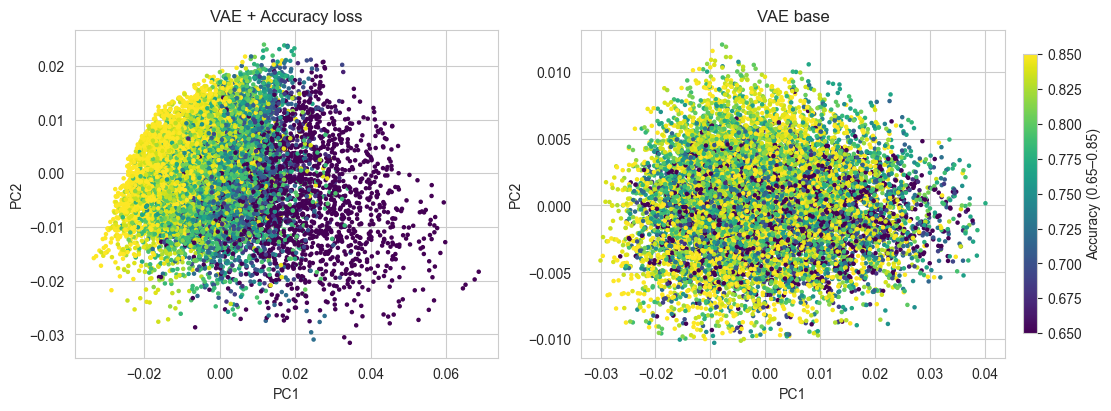

In [14]:
fig, axes = plot_latent_comparison(
    z_2d_vae_acc,
    z_2d_vae,
    y_train
)

### Flow matching 

#### training and visualization 

to test Flow Matching:
1. for every architecture embedding $z_i$ find a neighbor $z_j$ with a better accuracy by at least a $\Delta$ 
2. Train Flow Matching using as a target direction the vector from $z_i$ to $z_j$

In [15]:
pairs_x, pairs_target = build_accuracy_pairs(
    X=z,
    y=y_train,
    K=50,
    min_delta_acc=0.005,
    seed=SEED
)

Number of pairs: 12029


In [42]:
set_seed(49)
flow = FlowNet(dim=16).to(DEVICE)
optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)

pairs_x = pairs_x.to(DEVICE)
pairs_target = pairs_target.to(DEVICE)
epochs = 100

for epoch in range(epochs):
    pred = flow(pairs_x)
    loss = ((pred - pairs_target) ** 2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch} | Loss {loss.item():.6f}"
        )

Epoch 0 | Loss 0.005181
Epoch 50 | Loss 0.000004


plotting flow field:

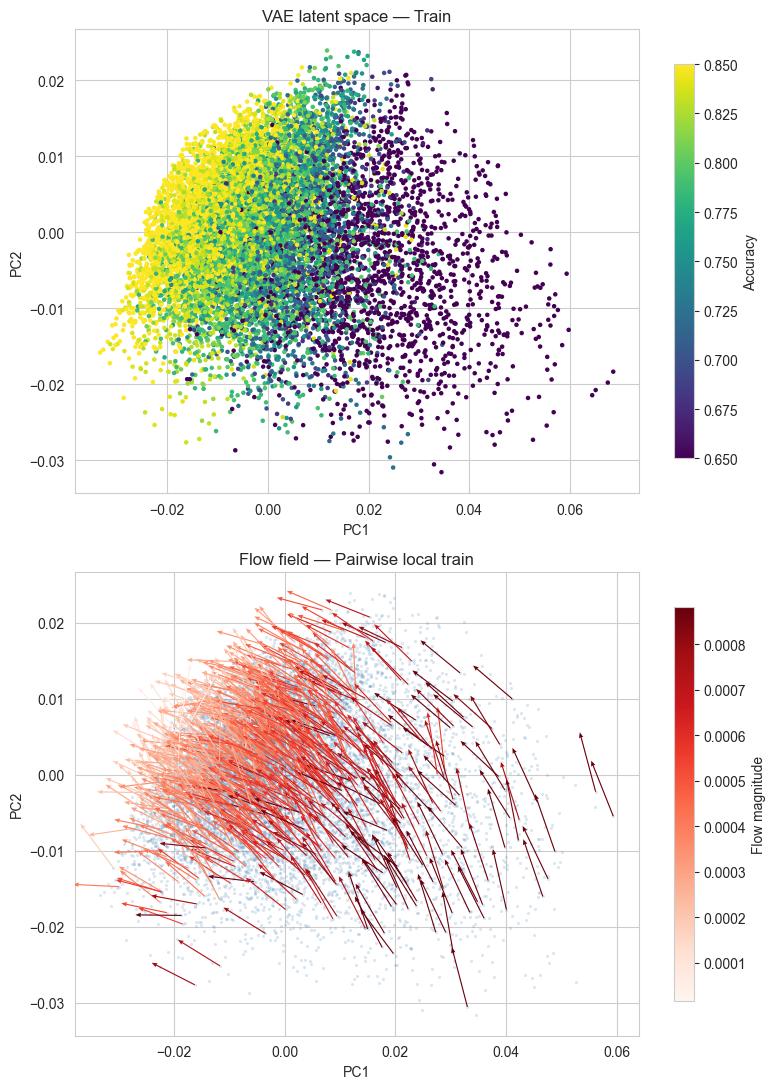

In [54]:
flow.eval()

z_low = pairs_x.detach().to(DEVICE)

with torch.no_grad():
    v_new = flow(z_low)

z_low_np = z_low.detach().cpu().numpy()
v_new_np = v_new.detach().cpu().numpy()

z_low_2d = pca.transform(z_low_np)
z_next_2d = pca.transform(z_low_np + v_new_np)
v_2d = z_next_2d - z_low_2d

v_mag = np.linalg.norm(v_2d, axis=1)
v_norm = v_2d / (v_mag[:, None] + 1e-8)

arrow_len = min(
    np.ptp(z_low_2d[:, 0]),
    np.ptp(z_low_2d[:, 1])
) * 0.15

idx = np.random.choice(
    len(z_low_2d),
    size=min(800, len(z_low_2d)),
    replace=False
)

# Conversione necessaria per Matplotlib
if torch.is_tensor(z_2d_vae_acc):
    z_2d_vae_acc = z_2d_vae_acc.detach().cpu().numpy()

if torch.is_tensor(y_train):
    y_train = y_train.detach().cpu().numpy()

"""fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)"""

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 11)
)

sc0 = axes[0].scatter(
    z_2d_vae_acc[:, 0],
    z_2d_vae_acc[:, 1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)

axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

fig.colorbar(
    sc0,
    ax=axes[0],
    shrink=0.85
).set_label("Accuracy")

axes[1].scatter(
    z_low_2d[:, 0],
    z_low_2d[:, 1],
    color="steelblue",
    s=5,
    alpha=0.2,
    linewidths=0,
    zorder=2
)

q = axes[1].quiver(
    z_low_2d[idx, 0],
    z_low_2d[idx, 1],
    v_norm[idx, 0] * arrow_len,
    v_norm[idx, 1] * arrow_len,
    v_mag[idx],
    cmap="Reds",
    norm=plt.Normalize(
        vmin=v_mag.min(),
        vmax=np.percentile(v_mag, 95)
    ),
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.002,
    headwidth=4,
    headlength=5,
    alpha=1,
    zorder=3
)

axes[1].set_title("Flow field — Pairwise local train")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.colorbar(
    q,
    ax=axes[1],
    shrink=0.85
).set_label("Flow magnitude")

plt.show()

# NAS301

## dataset laoding

In [ ]:
def load_csv_as_dataset(csv_path):
    df = pd.read_csv(csv_path)
    feature_cols = [col for col in df.columns if col.startswith("x_")]

    feature_cols = sorted(
        feature_cols,
        key=lambda c: int(c.split("_")[1])
    )

    X = df[feature_cols].values
    Y = df["accuracy"].values

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    dataset = TensorDataset(X, Y)

    print("CSV caricato:", csv_path)
    print("Numero esempi:", len(dataset))
    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Accuracy min:", Y.min().item())
    print("Accuracy max:", Y.max().item())

    return X, Y, dataset

x, y, dataset_301 = load_csv_as_dataset(
    "datasets/nas301/nas301_dataset.csv"
)

CSV caricato: datasets/nas301/nas301_dataset.csv
Numero esempi: 50000
X shape: torch.Size([50000, 504])
Y shape: torch.Size([50000])
Accuracy min: 0.8962019085884094
Accuracy max: 0.9467961192131042



These utility functions are used to move between the DARTS/NAS301 genotype representation and the tensor representation used by the VAE.

- `cell_to_tensor(cell_edges)` converts a single DARTS cell into a one-hot tensor of shape `(N_OPS, TOTAL_NODES, TOTAL_NODES)`. Each active edge is represented by setting to `1` the position corresponding to its operation, source node and destination node.

- `genotype_to_tensor(genotype)` converts a full DARTS genotype into a flattened tensor. Since a NAS301 architecture contains two cells, normal and reduction, the final tensor has shape `(2, 7, 6, 6)`, flattened into a vector of size `504`.

- `tensor_to_cell(x_cell)` performs the inverse operation for a single cell. For each intermediate node, it selects the two best incoming source nodes and the best operation associated with each source. This produces a valid DARTS cell with exactly two incoming edges per intermediate node.

- `tensor_to_genotype(x)` converts a full tensor representation back into a DARTS `Genotype`, reconstructing both the normal and reduction cells.



In [ ]:
if isinstance(x, torch.Tensor):
    x = x.detach().cpu().float()

x = torch.tensor(x, dtype=torch.float32)

idx = 0

x_original, y_original = dataset_301[idx]

print("Original x shape:", x_original.shape)
print("Original y:", y_original)

Original x shape: torch.Size([504])
Original y: tensor(0.9334)


from tensor to genotype:

In [ ]:
genotype = tensor_to_genotype(x_original)

print("GENOTYPE:")
print(genotype)

GENOTYPE:
Genotype(normal=[('dil_conv_3x3', 0), ('skip_connect', 1), ('avg_pool_3x3', 0), ('dil_conv_3x3', 2), ('dil_conv_3x3', 0), ('sep_conv_5x5', 2), ('max_pool_3x3', 0), ('max_pool_3x3', 3)], normal_concat=[2, 3, 4, 5], reduce=[('avg_pool_3x3', 0), ('sep_conv_5x5', 1), ('sep_conv_5x5', 0), ('avg_pool_3x3', 2), ('sep_conv_3x3', 0), ('sep_conv_5x5', 3), ('dil_conv_5x5', 0), ('dil_conv_5x5', 2)], reduce_concat=[2, 3, 4, 5])


from genotype to tensor: 

In [ ]:
x_reconstructed = genotype_to_tensor(genotype)

x_reconstructed = torch.tensor(
    x_reconstructed,
    dtype=torch.float32
).view(-1)

print("Reconstructed x shape:", x_reconstructed.shape)

Reconstructed x shape: torch.Size([504])
